# RFM Analysis Verification - Gold Layer
This notebook verifies the results of the RFM segmentation job executed on the Gold Layer.

In [1]:
import sys
import os
from pathlib import Path

# Automatic Project Root Discovery
def find_project_root():
    cwd = os.getcwd()
    while cwd != os.path.dirname(cwd):
        if os.path.exists(os.path.join(cwd, 'src')):
            return cwd
        cwd = os.path.dirname(cwd)
    return None

root = find_project_root()
if root:
    print(f"Project root found: {root}")
    if root not in sys.path:
        sys.path.insert(0, root)
else:
    print("CRITICAL: Project root not found. Please ensure 'src' folder is reachable.")

from src.spark_session import get_spark_session
from src.config import get_gold_table_path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("Initializing Spark Session...")
spark = get_spark_session("RFM_Verification_Notebook")
print("Spark Session initialized successfully!")

Project root found: /home/jovyan/work
Initializing Spark Session...
Spark Session initialized successfully!


## 1. Check Gold Tables
Verify if the `gold_rfm_segments` table exists in the Hive Metastore. If not, we will try to register it manually.

In [2]:
table_name = "default.gold_rfm_segments"
try:
    print("Listing gold tables in Metadata Layer...")
    spark.sql("SHOW TABLES IN default LIKE 'gold*' ").show()
    
    # Check if we can actually query it
    spark.table(table_name).limit(1).collect()
    print(f"SUCCESS: Table {table_name} is registered and reachable.")
except Exception as e:
    print(f"Table {table_name} not found or error: {str(e)}")
    print("Attempting to register table from S3 location...")
    gold_path = get_gold_table_path("rfm_segments")
    spark.sql(f"CREATE TABLE IF NOT EXISTS {table_name} USING DELTA LOCATION '{gold_path}'")
    print(f"Registration complete for {table_name} at {gold_path}")

Listing gold tables in Metadata Layer...
+---------+---------+-----------+
|namespace|tableName|isTemporary|
+---------+---------+-----------+
+---------+---------+-----------+

Table default.gold_rfm_segments not found or error: [TABLE_OR_VIEW_NOT_FOUND] The table or view `default`.`gold_rfm_segments` cannot be found. Verify the spelling and correctness of the schema and catalog.
If you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.
To tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS.;
'UnresolvedRelation [default, gold_rfm_segments], [], false

Attempting to register table from S3 location...
Registration complete for default.gold_rfm_segments at s3a://gold/rfm_segments


## 2. Customer Segmentation Distribution
Analyzing the count of customers and average monetary value for each segment.

In [3]:
dist_df = spark.sql("""
    SELECT 
        rfm_segment, 
        COUNT(*) as customer_count, 
        ROUND(AVG(monetary), 2) as avg_monetary,
        ROUND(AVG(recency), 2) as avg_recency,
        ROUND(AVG(frequency), 2) as avg_frequency
    FROM default.gold_rfm_segments 
    GROUP BY rfm_segment 
    ORDER BY customer_count DESC
""").toPandas()

display(dist_df)

,rfm_segment,customer_count,avg_monetary,avg_recency,avg_frequency
0,Recent Customers,18290,99.49,64.78,1.02
1,Lost Customers,17815,87.18,458.74,1.00
2,At Risk,17713,89.16,283.89,1.00
3,General Customers,17570,89.42,173.30,1.00
4,Big Spenders,16465,388.10,305.41,1.00
5,Champions/VIP,5600,400.97,59.64,1.12
6,Loyal Customers,2107,299.40,290.85,2.10


## 3. Visualization
Plotting the segments to better understand the customer base.

/tmp/ipykernel_1207/3568924289.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, x='customer_count', y='rfm_segment', palette='viridis')


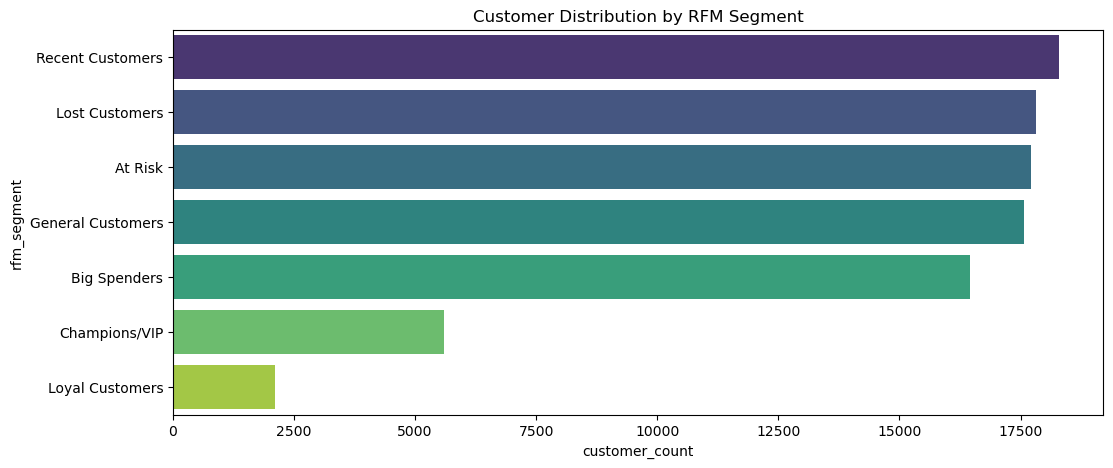

/tmp/ipykernel_1207/3568924289.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dist_df, x='avg_monetary', y='rfm_segment', palette='magma')


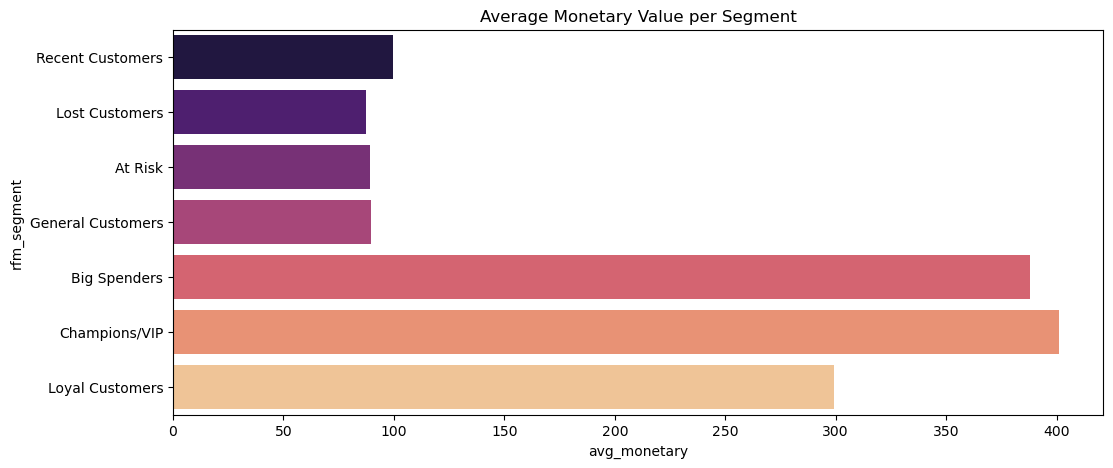

In [4]:
if not dist_df.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=dist_df, x='customer_count', y='rfm_segment', palette='viridis')
    plt.title('Customer Distribution by RFM Segment')
    plt.show()

    plt.figure(figsize=(12, 5))
    sns.barplot(data=dist_df, x='avg_monetary', y='rfm_segment', palette='magma')
    plt.title('Average Monetary Value per Segment')
    plt.show()
else:
    print("No data available for plotting.")

## 4. Sample Data: Champions/VIP
Viewing a sample of top customers in the Champions/VIP segment.

In [5]:
spark.sql("""
    SELECT customer_unique_id, frequency, monetary, recency, rfm_segment 
    FROM default.gold_rfm_segments 
    WHERE rfm_segment = 'Champions/VIP' 
    ORDER BY monetary DESC 
    LIMIT 10
""").toPandas()

,customer_unique_id,frequency,monetary,recency,rfm_segment
0,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,51,Champions/VIP
1,459bef486812aa25204be022145caa62,1,6922.21,41,Champions/VIP
2,48e1ac109decbb87765a3eade6854098,1,4681.78,74,Champions/VIP
3,c8460e4251689ba205045f3ea17884a1,4,4655.88,27,Champions/VIP
4,edde2314c6c30e864a128ac95d6b2112,1,4513.32,32,Champions/VIP
5,a229eba70ec1c2abef51f04987deb7a5,1,4445.50,96,Champions/VIP
6,ca27f3dac28fb1063faddd424c9d95fa,1,4163.51,37,Champions/VIP
7,58483a1c055dfb600f57c5b867174542,1,4034.44,91,Champions/VIP
8,95a744604de66a2e40e18086e69be4f2,1,3406.47,60,Champions/VIP
9,ce3fe361f9e68bf0a813baaae1334d01,1,3351.35,20,Champions/VIP
